<a href="https://colab.research.google.com/github/karna-charan/-Neural-Networks-and-Deep-Learning-/blob/main/braintumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install tensorflow kagglehub


In [4]:
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import os

# -----------------------------
# Download dataset from Kaggle
# -----------------------------
dataset_path = kagglehub.dataset_download("abhranta/brain-tumor-detection-mri")
print("Dataset downloaded to:", dataset_path)

# The actual images are inside the folder:
# Brain_Tumor_Detection
data_dir = os.path.join(dataset_path, "Brain_Tumor_Detection")

# -----------------------------
# Image settings
# -----------------------------
img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    classes=['no', 'yes']
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    classes=['no', 'yes']
)

# -----------------------------
# CNN Model
# -----------------------------
model = Sequential([
    Input(shape=(img_size, img_size, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train model
# -----------------------------
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

# -----------------------------
# Save model
# -----------------------------
model.save("brain_tumor_model.h5")
print("Model saved as brain_tumor_model.h5")


100%|██████████| 64.3M/64.3M [00:00<00:00, 84.5MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/abhranta/brain-tumor-detection-mri/versions/1
Found 2400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 76s 977ms/step - accuracy: 0.7125 - loss: 0.6045 - val_accuracy: 0.7900 - val_loss: 0.4729
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 987ms/step - accuracy: 0.8429 - loss: 0.3561 - val_accuracy: 0.8950 - val_loss: 0.2557
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 984ms/step - accuracy: 0.9018 - loss: 0.2606 - val_accuracy: 0.9500 - val_loss: 0.1536
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 72s 962ms/step - accuracy: 0.9423 - loss: 0.1560 - val_accuracy: 0.9583 - val_loss: 0.1245
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 83s 981ms/step - accuracy: 0.9673 - loss: 0.0963 - val_accuracy: 0.9767 - val_loss: 0.0588
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9857 - loss: 0.0544 - val_accuracy: 0.9783 - val_loss: 0.0605
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 983ms/step - accuracy: 0.9839 - loss: 0.0456 - val_accuracy: 0.9933 - val_loss: 0.0302
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 74s 983ms/step - accuracy: 0.9922 - loss: 0.0278 - val_accuracy: 0.9933 -

Model saved as brain_tumor_model.h5


In [20]:
from google.colab import files
import io
from PIL import Image
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# --- Image Upload ---
uploaded = files.upload()

uploaded_image_path = None
for fn in uploaded.keys():
  img_bytes = uploaded[fn]
  image = Image.open(io.BytesIO(img_bytes))
  uploaded_image_path = f'/tmp/{fn}'
  image.save(uploaded_image_path)
  print(f"User uploaded file \"{fn}\" saved to {uploaded_image_path}")
  break # Process only the first uploaded image

# --- Model Prediction ---
if uploaded_image_path:
    model = load_model("brain_tumor_model.h5")

    img = cv2.imread(uploaded_image_path)

    if img is None:
        print(f"Error: Could not load image from {uploaded_image_path}. Please ensure the file was uploaded correctly.")
    else:
        img = cv2.resize(img, (128,128))
        img = img / 255.0
        img = np.reshape(img, (1,128,128,3))

        prediction = model.predict(img)

        if prediction[0][0] > 0.5:
            print("Tumor Detected")
        else:
            print("No Tumor")
else:
    print("No image was uploaded. Please upload an image to proceed with prediction.")

Saving Tr-me_1326.jpg to Tr-me_1326.jpg
User uploaded file "Tr-me_1326.jpg" saved to /tmp/Tr-me_1326.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Tumor Detected


In [21]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

print(f"Training Accuracy: {train_acc[-1]:.4f}")
print(f"Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Training Loss: {train_loss[-1]:.4f}")
print(f"Validation Loss: {val_loss[-1]:.4f}")

Training Accuracy: 0.9942
Validation Accuracy: 0.9817
Training Loss: 0.0184
Validation Loss: 0.0388


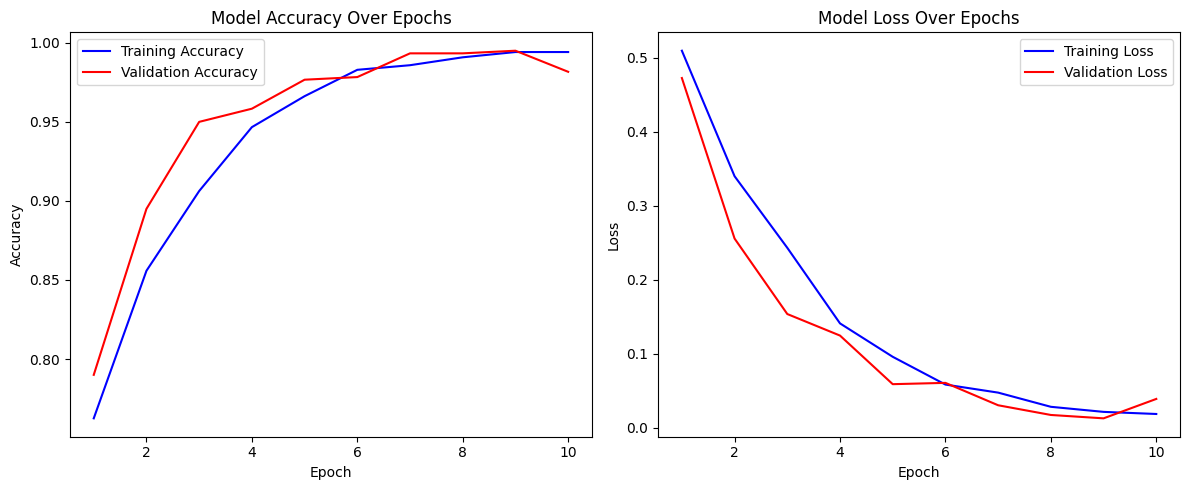

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
import gradio as gr
import numpy as np
import cv2

def predict_mri(image):
    image = cv2.resize(image, (128,128))
    image = image / 255.0
    image = image.reshape(1,128,128,3)

    prediction = model.predict(image)

    if prediction[0][0] > 0.5:
        return "Tumor Detected"
    else:
        return "No Tumor Detected"

interface = gr.Interface(
    fn=predict_mri,
    inputs=gr.Image(type="numpy"),
    outputs="text",
    title="Brain Tumor Detection Dashboard",
    description="Upload an MRI image to detect tumor"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b10b89b62a700d474a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
